### t3  pretreatment

#### 拟合附件三数据

In [1]:
# 拟合附件三数据
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 读取数据
data = pd.read_excel('附件3-弹性模量与压力.xlsx', sheet_name='Sheet1')

x = data['压力(MPa)']
y = data['弹性模量(MPa)']

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

In [2]:
# 多项式拟合
degree = 5
coeffs = np.polyfit(x, y, degree)
poly_func = np.poly1d(coeffs)

# 计算R²
y_pred = poly_func(x)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

#### print

In [3]:
# # 绘图
# plt.figure(figsize=(10, 6))

# # 绘制原始数据点
# plt.scatter(x, y, color='black', s=1, alpha=0.7, label='原始数据', zorder=5)

# # 生成平滑的拟合曲线
# x_smooth = np.linspace(x.min(), x.max(), 300)
# y_smooth = poly_func(x_smooth)

# # 绘制拟合曲线
# plt.plot(x_smooth, y_smooth, color='red', linewidth=2, 
#          label=f'三次多项式拟合 (R^2={r_squared:.10f})')

# plt.xlabel('压力 (MPa)', fontsize=12)
# plt.ylabel('弹性模量 (MPa)', fontsize=12)
# plt.title('弹性模量与压力的三次多项式拟合', fontsize=14)
# plt.legend(fontsize=10)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

#### 残差分析

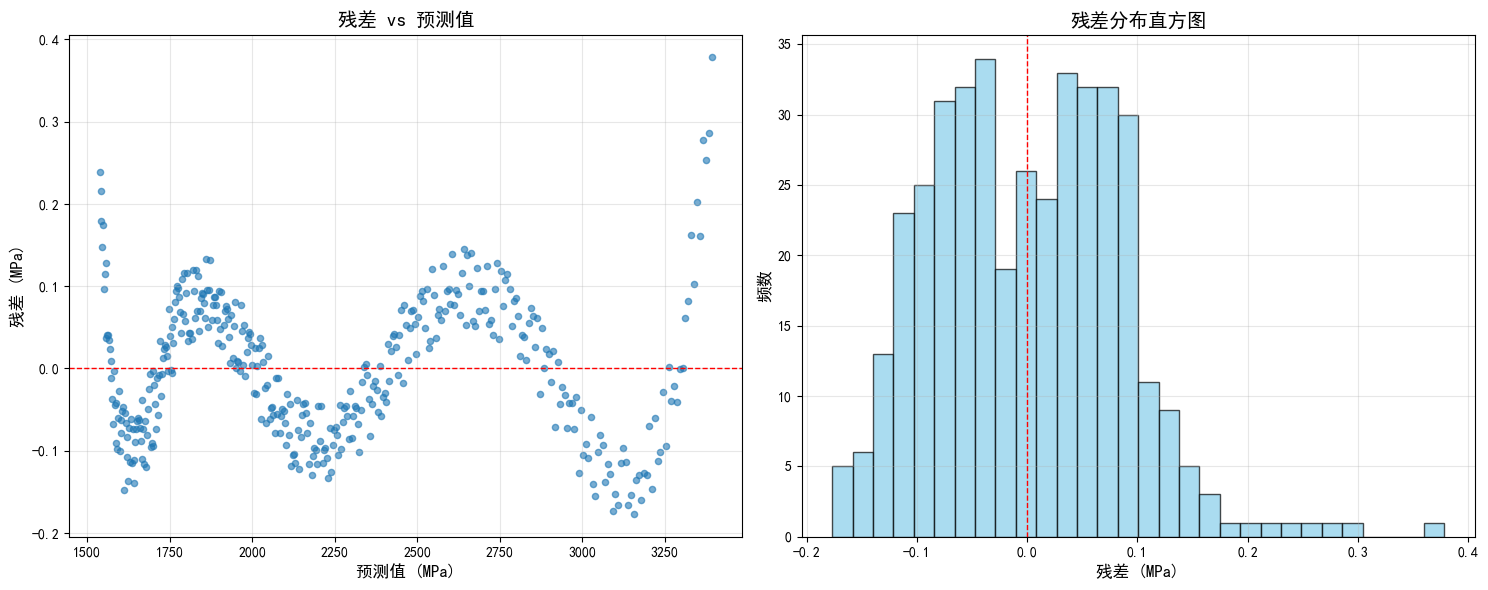


=== 残差分析 ===
残差均值: 0.000000 MPa
残差标准差: 0.085766 MPa
最大正残差: 0.378196 MPa
最大负残差: -0.176705 MPa
残差绝对值最大值: 0.378196 MPa


In [4]:
# 计算残差
residuals = y - y_pred

# 创建残差图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 残差 vs 预测值图
ax1.scatter(y_pred, residuals, alpha=0.6, s=20)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax1.set_xlabel('预测值 (MPa)', fontsize=12)
ax1.set_ylabel('残差 (MPa)', fontsize=12)
ax1.set_title('残差 vs 预测值', fontsize=14)
ax1.grid(True, alpha=0.3)

# 残差分布直方图
ax2.hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax2.set_xlabel('残差 (MPa)', fontsize=12)
ax2.set_ylabel('频数', fontsize=12)
ax2.set_title('残差分布直方图', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印残差统计信息
print(f"\n=== 残差分析 ===")
print(f"残差均值: {np.mean(residuals):.6f} MPa")
print(f"残差标准差: {np.std(residuals):.6f} MPa")
print(f"最大正残差: {np.max(residuals):.6f} MPa")
print(f"最大负残差: {np.min(residuals):.6f} MPa")
print(f"残差绝对值最大值: {np.max(np.abs(residuals)):.6f} MPa")

#### func

In [5]:
# # 打印拟合结果
# print(f"\n{degree}次多项式拟合结果:")
# print(f"R² = {r_squared:.6f}")
# print(f"多项式系数: {coeffs}")

# # 构建方程字符串
# equation = "y = "
# for j, coeff in enumerate(coeffs):
#     power = degree - j
#     if j == 0:
#         if power == 1:
#             equation += f"{coeff:.6e}*x"
#         elif power == 0:
#             equation += f"{coeff:.6e}"
#         else:
#             equation += f"{coeff:.6e}*x^{power}"
#     else:
#         if coeff >= 0:
#             sign = " + "
#         else:
#             sign = " - "
#             coeff = abs(coeff)
        
#         if power == 1:
#             equation += f"{sign}{coeff:.6e}*x"
#         elif power == 0:
#             equation += f"{sign}{coeff:.6e}"
#         else:
#             equation += f"{sign}{coeff:.6e}*x^{power}"

# print(f"拟合方程: {equation}")

#### E = func(P)

In [6]:
# 多项式预测功能
def E_func(pressure):
    """
    根据压力预测弹性模量（使用5次多项式）
    参数:
    pressure: 压力值(MPa)
    
    返回:
    弹性模量预测值(MPa)
    """
    return poly_func(pressure)

#### ρ(P)

In [7]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 定义微分方程 d(rho)/dP = rho / E(P)
def drho_dP(P, rho):
    return rho / E_func(P)

# 3. 设置初始条件
P0 = 100      # 初始压力 (MPa)
rho0 = 0.850  # 初始密度 (mg/mm^3)

# 4. 设置求解的压力范围 (例如 0.01 到 200 MPa)
P_min = 0
P_max = 200

In [8]:
# --- 第一部分：向前积分 (从 100 到 200) ---
P_span_fwd = (P0, P_max)
P_eval_fwd = np.linspace(P_span_fwd[0], P_span_fwd[1], 10000001)
sol_fwd = solve_ivp(
    fun=drho_dP,
    t_span=P_span_fwd,
    y0=[rho0],
    t_eval=P_eval_fwd,
    method='RK45'
)

# --- 第二部分：向后积分 (从 100 到 0.01) ---
# 只需要将积分区间反向即可
P_span_bwd = (P0, P_min)
P_eval_bwd = np.linspace(P_span_bwd[0], P_span_bwd[1], 10000001)
sol_bwd = solve_ivp(
    fun=drho_dP,
    t_span=P_span_bwd,
    y0=[rho0],
    t_eval=P_eval_bwd,
    method='RK45'
)

In [9]:
# 5. 合并和整理结果
# 向后积分的结果是 P 值递减的，我们需要将其翻转过来
P_bwd_sorted = np.flip(sol_bwd.t)
rho_bwd_sorted = np.flip(sol_bwd.y[0])

# 将两部分结果拼接在一起
# 注意：P=100 的点会在两部分结果中都出现，所以我们去掉一个
P_values = np.concatenate((P_bwd_sorted[:-1], sol_fwd.t))
rho_values = np.concatenate((rho_bwd_sorted[:-1], sol_fwd.y[0]))

#### print 

In [10]:
# # 6. 验证和可视化
# print(f"在 P={P_values[np.where(P_values == 160)[0][0]]:.6f} MPa 时, 密度为 {rho_values[np.where(P_values == 160)[0][0]]:.6f} mg/mm³")
# plt.figure(figsize=(12, 7))
# plt.plot(P_values, rho_values, label='ρ(P) 数值解')
# plt.xlabel("压力 P (MPa)")
# plt.ylabel("密度 ρ (mg/mm³)")
# plt.title("燃油密度与压力的关系")
# plt.grid(True)
# plt.legend()
# plt.show()

#### ρ(P) function

In [11]:
P_start = P_values[0]
P_stop = P_values[-1]
P_num_points = len(P_values)

# 预先计算步长
step = (P_stop - P_start) / (P_num_points - 1)

def rho(P):
    index = int(round((P - P_start) / step))
    return rho_values[index]


In [12]:
rho(0)#rho_values[int(round((0 - P_start) / step))]#

0.8042873698181616

In [13]:

# degree = 4
# x = rho_values
# y = P_values
# coeffs_2 = np.polyfit(x, y, degree)
# poly_func_2 = np.poly1d(coeffs_2)
# print("success")
# # 计算R²
# y_pred = poly_func_2(x)
# ss_res = np.sum((y - y_pred) ** 2)
# ss_tot = np.sum((y - np.mean(y)) ** 2)
# r_squared = 1 - (ss_res / ss_tot)
# print(r_squared)

# xx = np.linspace(0.804287, 0.882576, 78290)

# # 计算数组中每个 x 值的 poly_func_2(x)
# result_array = poly_func_2(xx)

# # 打印结果数组的前几个值
# print(result_array[:5])
# print(poly_func_2(0.8042873698181616))

#### P(ρ) function

In [14]:
# 从 CSV 文件中加载数据，并直接转换为 NumPy 数组
P_array = np.array([])
df = pd.read_excel('Prho.xlsx')
P_array = df['P'].to_numpy()

rho_start = 804.3
rho_step = 0.001
def P_func(rho):
    rho = rho * 1000
    index = round((rho - rho_start) / rho_step)
    return P_array[index]


### t3 iter calculate

#### const from t2

In [29]:
from scipy.optimize import brentq
import math

# --- 1. 物理参数和常数定义 ---
L = 500  # 高压油管长度 (mm)
d = 10   # 高压油管内径 (mm)
V_pipe = math.pi * (d / 2)**2 * L  # 高压油管体积 (mm^3)

d_pump = 5  # 油泵直径 (mm)
d_A = 1.4  # A口小孔直径 (mm)
A_A = math.pi * (d_A / 2)**2  # A口小孔面积 (mm^2)
C = 0.85   # 流量系数
#P_pump = 160  # A口供油压力 (MPa)
P_pump_initial = 0.5

P_initial = 100  # 油管初始压力 (MPa)
#t_A_close = 10   # A口关闭时间 (ms)
T_total = 20000  # 工作总时间 (ms)
T_B = 100        # B口工作周期 (ms)
dt = 0.01        # 时间步长 (ms)
N_steps = int(T_total / dt)
time_grid = np.linspace(0, T_total, N_steps + 1)

n = 1
T_total_valid = int(n * T_total)
N_steps_valid = int(n * N_steps)
time_grid_valid = np.linspace(0, T_total_valid, N_steps_valid + 1)

# 从 CSV 文件中加载数据，并直接转换为 NumPy 数组
area_array = np.array([])
df = pd.read_excel('喷嘴面积.xlsx')
area_array = df['area'].to_numpy()

M_oilpump_initial = 92.3350768547823
rho_min = 0.8043  # 燃油最小密度 (mg/mm^3)


#### t3_1

In [16]:
import math
# 减压阀参数
d_D = 1.4  # 单向减压阀出口直径 (mm)
A_D = math.pi * (d_D / 2)**2 # 减压阀小孔面积 (mm^2) 

In [26]:
def simulate_pressure_with_Ta_PD_threshold(Ta_threshold):

    Ta, P_D_open_threshold = Ta_threshold
    
    P = np.zeros(N_steps + 1)
    P[0] = P_initial

    M_oilpump = np.zeros(N_steps + 1)
    M_oilpump[0] = M_oilpump_initial

    tk = 50
    def get_A_B(t):
        t = t % T_B
        if t < 2.45: return area_array[int(round(t*100))]
        elif tk <= t < tk + 2.45: return area_array[int(round((t-tk)*100))]
        else: return 0

    res = 0
    s = math.pi * (d_pump / 2)**2
    omega = 2 * math.pi / Ta

    def get_V_pump(t):
        return s * (3.432 + 2.413 * math.cos(omega * t))  

    for i in range(N_steps):
        t_current = time_grid[i]
        #print(f"当前时间: {t_current:.4f} ms")
        P_current = P[i]
        if 0 > P_current: return 2e15# 防止压力计算超出我们预设的插值范围
        # 返回一个很大的误差值，引导优化器避开此区域
        if P_current > 200: return 3e15
        rho_current = rho((P_current)) # 使传入的P四舍五入到6位小数
        #__________________________________________________________________________________________
        # A口
        M_oilpump_current = M_oilpump[i]
        if M_oilpump_current < 0: return -8e10
        
        V_pump = get_V_pump(t_current)

        if(M_oilpump_current <= V_pump * rho_min): 
            is_A_open = 0
            rho_oilpump = 0
            #print(rho_oilpump)
            Q_A = 0
        else: 
            is_A_open = 1
            rho_oilpump = (M_oilpump_current / V_pump)  # 使用当前油泵质量和体积计算密度
            #print(rho_oilpump)
            P_oilpump = P_func(rho_oilpump)  # 油泵压力 (MPa)
            if P_oilpump <= P_current: Q_A = 0  
            else: Q_A = C * A_A * math.sqrt(2 * (P_oilpump - P_current) / rho_oilpump)
        #__________________________________________________________________________________________
        # B口
        A_B = get_A_B(t_current)
        Q_B = C * A_B * math.sqrt(2 * (P_current) / rho_current)  # 假设B口压力为0 MPa
        #__________________________________________________________________________________________
        # D口
        if P_current > P_D_open_threshold:
            is_D_open = 1
        else:
            is_D_open = 0
        
        Q_D = C * A_D * math.sqrt(2 * (P_current) / rho_current) if is_D_open else 0
        #__________________________________________________________________________________________
        E_current = E_func(P_current)
        
        # 根据质量守恒计算净质量流速
        mass_flow_in =  Q_A * rho_oilpump
        mass_flow_out = Q_B * rho_current 
        mass_flow_out_D = Q_D * rho_current

        dM_dt = mass_flow_in - mass_flow_out - mass_flow_out_D
        
        # 根据物理关系 dP/dt = (E/rho/V) * dM/dt 计算压力变化率
        dP_dt = (E_current / (rho_current * V_pipe)) * dM_dt
        
        # 使用欧拉法更新下一时刻的压力
        P[i+1] = P_current + dP_dt * dt

        if (time_grid[i+1] % Ta) < (t_current % Ta): M_oilpump[i+1] = M_oilpump_initial
        else: M_oilpump[i+1] = M_oilpump_current - mass_flow_in * dt

        #if t_current % 1 == 0:
        res += (P_current - P_initial)**2

    return res / (N_steps+1) #T_total #


In [ ]:
import time
from scipy.optimize import root_scalar, minimize_scalar, minimize, differential_evolution
#ans = minimize_scalar(simulate_pressure, bounds=(T_A_start, T_A_stop), method='bounded')#, options={'xatol': 1e-8})

bounds = [(90, 130), (100, 105)]  # 参数边界
try:
    start_time = time.time()
    ans = differential_evolution(
        simulate_pressure_with_Ta_PD_threshold,
        bounds,
        # 您可以调整以下参数来控制搜索过程
        # strategy='best1bin', # 优化策略
        # maxiter=1000,      # 最大迭代次数
        # popsize=15,        # 种群大小
        # tol=0.01,          # 收敛容差
        # mutation=(0.5, 1), # 变异因子
        # recombination=0.7, # 重组概率
        disp=True          # 打印收敛过程
    )
    # ans = minimize(
    #     simulate_pressure_with_Ta_PD_threshold,                     
    #     x0=[120, 102],  # 初始猜测值
    #     bounds=[(90, 130), (100, 110)],       # 边界约束
    #     method='L-BFGS-B',                    # 优化方法
    #     options={
    #         'ftol': 1e-8,      # 收敛容差
    #         'maxiter': 50     # 最大迭代次数
    #     }
    # )
    end_time = time.time()
    if ans.success:
        print(f"找到的最优参数:")
        print(f"  参数1 (范围 90-130): {ans.x[0]:.14f}")
        print(f"  参数2 (范围 100-110): {ans.x[1]:.14f}")
        print(f"目标函数最小值: {ans.fun:.14f}")
        print(f"函数求值次数: {ans.nfev}")
        print(f"计算耗时: {(end_time - start_time)*1000:.1f} ms\n")
        # 验证结果
    else:
        print("求解失败")
        print(f"失败原因: {result.message}")

except Exception as e:
    print(f"\n发生错误: {e}\n")

#### t3_2  method2 is_D_open depend on A

In [44]:
def simulate_pressure_with_Ta_k1_k2(Ta_k1_k2):
    k1, k2 = Ta_k1_k2
    Ta = 50
    P = np.zeros(N_steps + 1)
    P[0] = P_initial

    M_oilpump = np.zeros(N_steps + 1)
    M_oilpump[0] = M_oilpump_initial

    tk = 50
    def get_A_B(t):
        t = t % T_B
        if t < 2.45: return area_array[int(round(t*100))]
        elif tk <= t < tk + 2.45: return area_array[int(round((t-tk)*100))]
        else: return 0

    res = 0
    s = math.pi * (d_pump / 2)**2
    omega = 2 * math.pi / Ta

    def get_V_pump(t):
        return s * (3.432 + 2.413 * math.cos(omega * t))  

    for i in range(N_steps):
        t_current = time_grid[i]
        #print(f"当前时间: {t_current:.4f} ms")
        P_current = P[i]
        if 0 > P_current: return 2e15# 防止压力计算超出我们预设的插值范围
        # 返回一个很大的误差值，引导优化器避开此区域
        if P_current > 200: return 3e15
        rho_current = rho((P_current)) # 使传入的P四舍五入到6位小数
        #__________________________________________________________________________________________
        # A口
        M_oilpump_current = M_oilpump[i]
        if M_oilpump_current < 0: return -8e10
        
        V_pump = get_V_pump(t_current)

        if(M_oilpump_current <= V_pump * rho_min): 
            rho_oilpump = 0
            #print(rho_oilpump)
            Q_A = 0
        else: 
            rho_oilpump = (M_oilpump_current / V_pump)  # 使用当前油泵质量和体积计算密度
            #print(rho_oilpump)
            if rho_oilpump > 0.882576: return 3e10
            P_oilpump = P_func(rho_oilpump)  # 油泵压力 (MPa)
            if P_oilpump <= P_current: Q_A = 0  
            else: Q_A = C * A_A * math.sqrt(2 * (P_oilpump - P_current) / rho_oilpump)
        #__________________________________________________________________________________________
        # B口
        A_B = get_A_B(t_current)
        Q_B = C * A_B * math.sqrt(2 * (P_current) / rho_current)  # 假设B口压力为0 MPa
        #__________________________________________________________________________________________
        # D口
        if Q_A == 0:
            is_D_open = 0
        else:
            if (Ta / 4 - k1) < (t_current % Ta) < (Ta / 4 + k2): is_D_open = 1
            else: is_D_open = 0
        
        Q_D = C * A_D * math.sqrt(2 * (P_current) / rho_current) if is_D_open else 0
        #__________________________________________________________________________________________
        E_current = E_func(P_current)
        
        # 根据质量守恒计算净质量流速
        mass_flow_in =  Q_A * rho_oilpump
        mass_flow_out = Q_B * rho_current 
        mass_flow_out_D = Q_D * rho_current

        dM_dt = mass_flow_in - mass_flow_out - mass_flow_out_D
        
        # 根据物理关系 dP/dt = (E/rho/V) * dM/dt 计算压力变化率
        dP_dt = (E_current / (rho_current * V_pipe)) * dM_dt
        
        # 使用欧拉法更新下一时刻的压力
        P[i+1] = P_current + dP_dt * dt

        if (time_grid[i+1] % Ta) < (t_current % Ta): M_oilpump[i+1] = M_oilpump_initial
        else: M_oilpump[i+1] = M_oilpump_current - mass_flow_in * dt

        #if t_current % 1 == 0:
        res += (P_current - P_initial)**2

    res = res / (N_steps+1)
    print(f"k1: {k1:.14f}, k2: {k2:.14f}, res: {res:.14f}")

    return res  #T_total #


In [46]:
import time
from scipy.optimize import root_scalar, minimize_scalar, minimize, differential_evolution, NonlinearConstraint
class ProgressTracker:
    def __init__(self):
        self.iteration = 0
        self.start_time = time.time()
    def __call__(self, xk, convergence):
        self.iteration += 1     
        print(f"Step {self.iteration:3d}: x = {xk}")# 打印格式化的进度

try:
    progress_tracker = ProgressTracker()

    start_time = time.time()
    def constraint_function(x):
        return np.array([
            x[1] - x[0]
        ])
    #    下界是 [0, 0]，上界是 [inf, inf]
    nonlinear_constraint = NonlinearConstraint(constraint_function, 0, np.inf)

    ans = differential_evolution(
        simulate_pressure_with_Ta_k1_k2,
        bounds=[(0, 5), (0, 10)],
        callback=progress_tracker,
        disp=True
    )
    
    end_time = time.time()
    if ans.success:
        print(f"找到的最优参数:")
        print(f"  参数1 (范围 90-130): {ans.x[0]:.14f}")
        print(f"  参数2 : {ans.x[1]:.14f}")
        print(f"  参数3 : {ans.x[2]:.14f}")
        print(f"目标函数最小值: {ans.fun:.14f}")
        print(f"函数求值次数: {ans.nfev}")
        print(f"计算耗时: {(end_time - start_time)*1000:.1f} ms\n")
        # 验证结果
    else:
        print("求解失败")
        print(f"失败原因: {ans.message}")

except Exception as e:
    print(f"\n发生错误: {e}\n")

k1: 4.02810919971558, k2: 7.77487965287276, res: 7669.05112992771865
k1: 2.65400597139919, k2: 6.34263592600438, res: 6515.28494413742737
k1: 4.76741374500088, k2: 0.51824674241331, res: 3253.17697019405068
k1: 0.59927779611458, k2: 8.79031531318374, res: 6760.13066524743772
k1: 1.82079431035935, k2: 4.78580519964617, res: 4771.82824812596573
k1: 4.51601038274280, k2: 2.55128243598817, res: 5140.77997819231769
k1: 1.98806436114507, k2: 7.37981425042566, res: 6720.54127994538612
k1: 3.00881296560477, k2: 8.28242984988358, res: 7519.96073837737367
k1: 0.17986223696473, k2: 6.94669300560700, res: 5259.07692285994563
k1: 4.36622221371011, k2: 8.57423063590829, res: 7987.60903816516748
k1: 2.48833501009643, k2: 7.16059353127802, res: 6855.85660949352769
k1: 2.18179096489698, k2: 1.22766728797569, res: 667.36224153358376
k1: 0.81303050492104, k2: 5.82465501785871, res: 4817.07693742440824
k1: 2.69209403959375, k2: 4.58298016518407, res: 5349.43644276333362
k1: 4.84351354536372, k2: 9.5875726

KeyboardInterrupt: 

In [ ]:
if ans.success:
        print(f"找到的最优参数:")
        print(f"  参数1 (范围 90-130): {ans.x[0]:.14f}")
        print(f"  参数2 : {ans.x[1]:.14f}")
        print(f"目标函数最小值: {ans.fun:.14f}")
        print(f"函数求值次数: {ans.nfev}")
        print(f"计算耗时: {(end_time - start_time)*1000:.1f} ms\n")

In [ ]:
def simulate_pressure_with_Ta_PD_threshold_valid(Ta_threshold):
    Ta, P_D_open_threshold = Ta_threshold
    
    P = np.zeros(N_steps + 1)
    P[0] = P_initial

    M_oilpump = np.zeros(N_steps + 1)
    M_oilpump[0] = M_oilpump_initial

    tk = 50
    def get_A_B(t):
        t = t % T_B
        if t < 2.45: return area_array[int(round(t*100))]
        elif tk <= t < tk + 2.45: return area_array[int(round((t-tk)*100))]
        else: return 0

    res = 0
    s = math.pi * (d_pump / 2)**2
    omega = 2 * math.pi / Ta

    def get_V_pump(t):
        return s * (3.432 + 2.413 * math.cos(omega * t))  

    for i in range(N_steps):
        t_current = time_grid[i]
        #print(f"当前时间: {t_current:.4f} ms")
        P_current = P[i]
        if 0 > P_current: return 2e15# 防止压力计算超出我们预设的插值范围
        # 返回一个很大的误差值，引导优化器避开此区域
        if P_current > 200: return 3e15
        rho_current = rho((P_current)) # 使传入的P四舍五入到6位小数
        #__________________________________________________________________________________________
        # A口
        M_oilpump_current = M_oilpump[i]
        if M_oilpump_current < 0: return -8e10
        
        V_pump = get_V_pump(t_current)

        if(M_oilpump_current <= V_pump * rho_min): 
            is_A_open = 0
            rho_oilpump = 0
            #print(rho_oilpump)
            Q_A = 0
        else: 
            is_A_open = 1
            rho_oilpump = (M_oilpump_current / V_pump)  # 使用当前油泵质量和体积计算密度
            #print(rho_oilpump)
            P_oilpump = P_func(rho_oilpump)  # 油泵压力 (MPa)
            if P_oilpump <= P_current: Q_A = 0  
            else: Q_A = C * A_A * math.sqrt(2 * (P_oilpump - P_current) / rho_oilpump)
        #__________________________________________________________________________________________
        # B口
        A_B = get_A_B(t_current)
        Q_B = C * A_B * math.sqrt(2 * (P_current) / rho_current)  # 假设B口压力为0 MPa
        #__________________________________________________________________________________________
        # D口
        if P_current > P_D_open_threshold:
            is_D_open = 1
        else:
            is_D_open = 0
        
        Q_D = C * A_D * math.sqrt(2 * (P_current) / rho_current) if is_D_open else 0
        #__________________________________________________________________________________________
        E_current = E_func(P_current)
        
        # 根据质量守恒计算净质量流速
        mass_flow_in =  Q_A * rho_oilpump
        mass_flow_out = Q_B * rho_current 
        mass_flow_out_D = Q_D * rho_current

        dM_dt = mass_flow_in - mass_flow_out - mass_flow_out_D
        
        # 根据物理关系 dP/dt = (E/rho/V) * dM/dt 计算压力变化率
        dP_dt = (E_current / (rho_current * V_pipe)) * dM_dt
        
        # 使用欧拉法更新下一时刻的压力
        P[i+1] = P_current + dP_dt * dt

        if (time_grid[i+1] % Ta) < (t_current % Ta): M_oilpump[i+1] = M_oilpump_initial
        else: M_oilpump[i+1] = M_oilpump_current - mass_flow_in * dt

    return P

P = simulate_pressure_with_Ta_PD_threshold_valid(ans.x) #121)#

In [ ]:
plt.figure(figsize=(20, 6))
plt.plot(time_grid_valid, P) #, P) #
plt.xlabel('时间 (ms)')
plt.ylabel('压力 (MPa)')
plt.xlim(0, 1000)
plt.grid(True)
plt.show()

####